In [151]:
import os
import pandas as pd
from PyPDF2 import PdfReader
import plotly.express as px
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse
import pdfplumber
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm
import nltk
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import re
from bs4 import BeautifulSoup
nltk.download('punkt')

tqdm.pandas()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/bellamendoza/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1 - Making DF of PDF file names and page counts

In [146]:
def get_pdf_page_counts(folder_path):
    data = []

    for filename in os.listdir(folder_path):
        if filename.lower().endswith('.pdf'):
            file_path = os.path.join(folder_path, filename)
            try:
                reader = PdfReader(file_path)
                page_count = len(reader.pages)
                data.append({'filename': filename, 'page_count': page_count})
            except Exception as e:
                print(f"Error reading {filename}: {e}")
                data.append({'filename': filename, 'page_count': None})

    df = pd.DataFrame(data)
    return df


folder = '../../data/90-fr-9088-combined-responses'
pdf_df = get_pdf_page_counts(folder)
pdf_df


,filename,page_count
0,AI-RFI-2025-8485.pdf,1
1,AI-RFI-2025-2816.pdf,1
2,RR-RFI-2025.pdf,1
3,AI-RFI-2025-0973.pdf,1
4,AI-RFI-2025-2802.pdf,1
...,...,...
10063,AI-RFI-2025-5806.pdf,2
10064,Washington-State-University-AI-RFI-2025.pdf,9
10065,ID4-AI-RFI-2025.pdf,4
10066,Workforce-AI-AI-RFI-2025.pdf,15


## 2 - Making visualization of page count

In [147]:
def plot_page_count_distribution(df):
    fig = px.histogram(
        df,
        x='page_count',
        nbins=100,
        title='PDF Page Count Distribution',
        labels={'page_count': 'Number of Pages'},
        template='ggplot2'
    )
    fig.update_layout(
        xaxis_title='Page Count',
        yaxis_title='Number of PDFs',
        bargap=0.1
    )
    fig.show()

plot_page_count_distribution(pdf_df)


In [148]:
pdf_df[pdf_df['page_count']>60]

,filename,page_count
76,Emory-University-AI-RFI-2025.pdf,62
669,AI-RFI-2025-1307.pdf,153
3238,HIA-AI-RFI-2025.pdf,63
4945,Dovev-Lavie-AI-RFI-2025.pdf,64
6521,Ryan-Abbott-AI-RFI-2025.pdf,66


Most of these comments with high page counts are including their academic papers or other resources. I'm making the decision to leave them here but may take them out later.

## 3 - Scrape text from PDFs

In [149]:
def extract_text_from_pdf(filepath):
    try:
        with pdfplumber.open(filepath) as pdf:
            text = ''
            for page in pdf.pages:
                text += page.extract_text() or ''
        return text.strip()
    except Exception as e:
        print(f"Error extracting {filepath}: {e}")
        return None

pdf_folder = "../../data/90-fr-9088-combined-responses"

pdf_df['text'] = pdf_df['filename'].progress_apply(
    lambda fname: extract_text_from_pdf(os.path.join(pdf_folder, fname))
)

  1%|▏         | 134/10068 [00:18<15:41, 10.55it/s] CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, de

In [150]:
pdf_df

,filename,page_count,text
0,AI-RFI-2025-8485.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
1,AI-RFI-2025-2816.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
2,RR-RFI-2025.pdf,1,3/12/2025 via FDMS\nR.R.\nOur world is driven ...
3,AI-RFI-2025-0973.pdf,1,"As of: March 21, 2025\nReceived: February 25, ..."
4,AI-RFI-2025-2802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
...,...,...,...
10063,AI-RFI-2025-5806.pdf,2,"As of: March 21, 2025\nReceived: March 15, 202..."
10064,Washington-State-University-AI-RFI-2025.pdf,9,Office of External Affairs and Government Rela...
10065,ID4-AI-RFI-2025.pdf,4,RFI: Request for Information on the Developmen...
10066,Workforce-AI-AI-RFI-2025.pdf,15,Opp Title: AI Action Plan\nDue Date & Time: Ma...


## 4 - Enrich data with respondent name and respondent type from the website

In [179]:
def extract_links_from_file(file_path):
    """
    Reads HTML content from a .txt file and extracts all <a> tag hrefs and display text.

    Args:
        file_path (str): Path to the .txt file containing HTML.

    Returns:
        pd.DataFrame: A DataFrame with columns ['link', 'respondent'].
    """
    with open(file_path, "r", encoding="utf-8") as file:
        html_string = file.read()

    soup = BeautifulSoup(html_string, "html.parser")
    links = soup.find_all("a")

    data = []
    for link in links:
        href = link.get("href")
        text = link.get_text(strip=True)
        if href and text:
            data.append((href, text))

    return pd.DataFrame(data, columns=["link", "respondent"])

academia_df = extract_links_from_file("../../data/website/academia_table.txt")
academia_df['Respondent Type'] = "academia"
individual_df = extract_links_from_file("../../data/website/individual_table.txt")
individual_df['Respondent Type'] = "individual"
industry_df = extract_links_from_file("../../data/website/industry_table.txt")
industry_df['Respondent Type'] = "industry"
nonfederal_government_df = extract_links_from_file("../../data/website/nonfederal_government_table.txt")
nonfederal_government_df['Respondent Type'] = "nonfederal government"
nonprofit_df = extract_links_from_file("../../data/website/nonprofit_table.txt")
nonprofit_df['Respondent Type'] = "nonprofit"
private_sector_df = extract_links_from_file("../../data/website/private_sector_table.txt")
private_sector_df['Respondent Type'] = "private sector"

dfs = [
    academia_df,
    individual_df,
    industry_df,
    nonfederal_government_df,
    nonprofit_df,
    private_sector_df
]

# Concatenate into one merged dataframe
all_responses_df = pd.concat(dfs, ignore_index=True)

# Extract the file name from the link and store it in a new column
all_responses_df["filename"] = all_responses_df["link"].str.extract(r'/([^/]+\.pdf)$')

# Merge the two DataFrames on 'filename'
responses_df = pd.merge(all_responses_df, pdf_df, on="filename", how="inner")

## 5 - Grab the substantive of the text

In [180]:
# 83% of these documents are in this same format, so let's program for this format first
formatted_submissions_df = responses_df[responses_df['text'].str.startswith("As of:")]
formatted_submissions_df


,link,respondent,Respondent Type,filename,page_count,text
0,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,AI in Education at Oxford University,academia,AI-RFI-2025-1398.pdf,10,"As of: March 21, 2025\nReceived: March 14, 202..."
3,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,AI Institute for Resilient Agriculture,academia,AI-RFI-2025-5437.pdf,2,"As of: March 21, 2025\nReceived: March 15, 202..."
6,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Arizona State University,academia,AI-RFI-2025-6964.pdf,11,"As of: March 21, 2025\nReceived: March 15, 202..."
10,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Beacon College,academia,AI-RFI-2025-1357.pdf,5,"As of: March 21, 2025\nReceived: March 14, 202..."
13,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Brooklyn Law Incubator & Policy Clinic,academia,AI-RFI-2025-1942.pdf,5,"As of: March 21, 2025\nReceived: March 15, 202..."
...,...,...,...,...,...,...
10026,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,TourScanner,private sector,AI-RFI-2025-2189.pdf,3,"As of: March 21, 2025\nReceived: March 15, 202..."
10029,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Trickster Media,private sector,AI-RFI-2025-5611.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
10036,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,"Uber Technologies, Inc.",private sector,AI-RFI-2025-1719.pdf,11,"As of: March 21, 2025\nReceived: March 15, 202..."
10053,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,WalletHub,private sector,AI-RFI-2025-1698.pdf,3,"As of: March 21, 2025\nReceived: March 15, 202..."


In [181]:
# Extract everything after "General Comment"
formatted_submissions_df['comment_only'] = formatted_submissions_df['text'].str.split('General Comment', n=1).str[-1].str.strip()

# Remove \n
formatted_submissions_df['comment_only'].str.replace('\n', '', regex=False)

/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/1825816254.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



0        Please see the attached file(s) which contains...
3        Subject: Response to Request for Information o...
6        See attachment.AttachmentsASU Response to OSTP...
10       See attached file(s)AttachmentsAI Request for ...
13       See attached file(s)AttachmentsBLIP CommentBro...
                               ...                        
10026    See attached file(s)AttachmentsAI Action Plan ...
10029    Absolutely do not give OPEN AI this access. Th...
10036    Please see attached comments on behalf of Uber...
10053    See attached file(s)AttachmentsRequest for Inf...
10058    Please find the attached comments from Wiz in ...
Name: comment_only, Length: 8374, dtype: object

## 5 - Analyze the formatted submissions

### Sentiment Analysis of full comment only text

In [182]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(comment):
    scores = analyzer.polarity_scores(comment)
    return scores['compound']

formatted_submissions_df['vader_score'] = formatted_submissions_df['comment_only'].progress_apply(vader_score)


100%|██████████| 8374/8374 [02:13<00:00, 62.70it/s] 
/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/2590929040.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [183]:
formatted_submissions_df

,link,respondent,Respondent Type,filename,page_count,text,comment_only,vader_score
0,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,AI in Education at Oxford University,academia,AI-RFI-2025-1398.pdf,10,"As of: March 21, 2025\nReceived: March 14, 202...",Please see the attached file(s) which contains...,1.0000
3,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,AI Institute for Resilient Agriculture,academia,AI-RFI-2025-5437.pdf,2,"As of: March 21, 2025\nReceived: March 15, 202...",Subject: Response to Request for Information o...,0.9981
6,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Arizona State University,academia,AI-RFI-2025-6964.pdf,11,"As of: March 21, 2025\nReceived: March 15, 202...",See attachment.\nAttachments\nASU Response to ...,0.9999
10,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Beacon College,academia,AI-RFI-2025-1357.pdf,5,"As of: March 21, 2025\nReceived: March 14, 202...",See attached file(s)\nAttachments\nAI Request ...,0.9998
13,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Brooklyn Law Incubator & Policy Clinic,academia,AI-RFI-2025-1942.pdf,5,"As of: March 21, 2025\nReceived: March 15, 202...",See attached file(s)\nAttachments\nBLIP Commen...,0.9988
...,...,...,...,...,...,...,...,...
10026,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,TourScanner,private sector,AI-RFI-2025-2189.pdf,3,"As of: March 21, 2025\nReceived: March 15, 202...",See attached file(s)\nAttachments\nAI Action P...,0.9348
10029,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Trickster Media,private sector,AI-RFI-2025-5611.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Absolutely do not give OPEN AI this access. Th...,-0.9100
10036,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,"Uber Technologies, Inc.",private sector,AI-RFI-2025-1719.pdf,11,"As of: March 21, 2025\nReceived: March 15, 202...",Please see attached comments on behalf of Uber...,0.9999
10053,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,WalletHub,private sector,AI-RFI-2025-1698.pdf,3,"As of: March 21, 2025\nReceived: March 15, 202...",See attached file(s)\nAttachments\nRequest for...,0.9929


In [184]:
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

formatted_submissions_df['textblob_score'] = formatted_submissions_df['comment_only'].progress_apply(get_textblob_sentiment)

100%|██████████| 8374/8374 [00:06<00:00, 1339.58it/s]
/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/2208390590.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [185]:
formatted_submissions_df

,link,respondent,Respondent Type,filename,page_count,text,comment_only,vader_score,textblob_score
0,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,AI in Education at Oxford University,academia,AI-RFI-2025-1398.pdf,10,"As of: March 21, 2025\nReceived: March 14, 202...",Please see the attached file(s) which contains...,1.0000,0.121372
3,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,AI Institute for Resilient Agriculture,academia,AI-RFI-2025-5437.pdf,2,"As of: March 21, 2025\nReceived: March 15, 202...",Subject: Response to Request for Information o...,0.9981,0.133844
6,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Arizona State University,academia,AI-RFI-2025-6964.pdf,11,"As of: March 21, 2025\nReceived: March 15, 202...",See attachment.\nAttachments\nASU Response to ...,0.9999,0.113355
10,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Beacon College,academia,AI-RFI-2025-1357.pdf,5,"As of: March 21, 2025\nReceived: March 14, 202...",See attached file(s)\nAttachments\nAI Request ...,0.9998,0.171172
13,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Brooklyn Law Incubator & Policy Clinic,academia,AI-RFI-2025-1942.pdf,5,"As of: March 21, 2025\nReceived: March 15, 202...",See attached file(s)\nAttachments\nBLIP Commen...,0.9988,0.073065
...,...,...,...,...,...,...,...,...,...
10026,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,TourScanner,private sector,AI-RFI-2025-2189.pdf,3,"As of: March 21, 2025\nReceived: March 15, 202...",See attached file(s)\nAttachments\nAI Action P...,0.9348,0.151256
10029,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Trickster Media,private sector,AI-RFI-2025-5611.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Absolutely do not give OPEN AI this access. Th...,-0.9100,0.113462
10036,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,"Uber Technologies, Inc.",private sector,AI-RFI-2025-1719.pdf,11,"As of: March 21, 2025\nReceived: March 15, 202...",Please see attached comments on behalf of Uber...,0.9999,0.089930
10053,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,WalletHub,private sector,AI-RFI-2025-1698.pdf,3,"As of: March 21, 2025\nReceived: March 15, 202...",See attached file(s)\nAttachments\nRequest for...,0.9929,0.133488


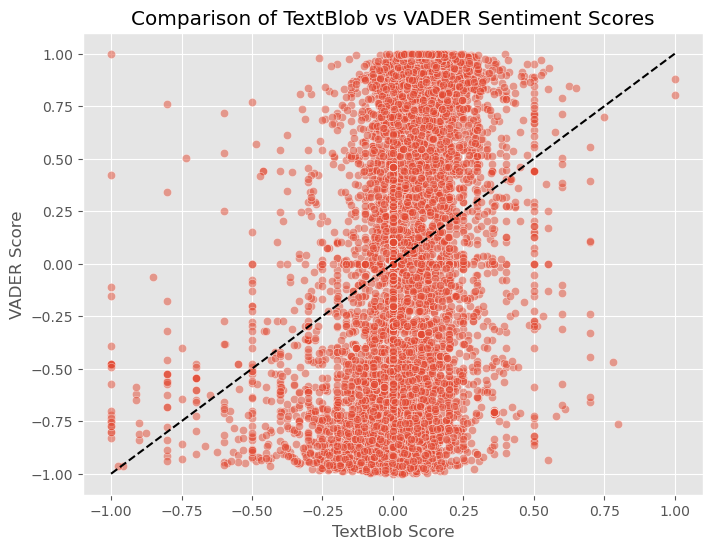

In [186]:
plt.style.use('ggplot')
plt.figure(figsize=(8,6))
sns.scatterplot(data=formatted_submissions_df, x='textblob_score', y='vader_score', alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='black', linestyle='--')
plt.title('Comparison of TextBlob vs VADER Sentiment Scores')
plt.xlabel('TextBlob Score')
plt.ylabel('VADER Score')
plt.grid(True)
plt.show()


In [187]:
formatted_submissions_df['score_difference'] = formatted_submissions_df['vader_score'] - formatted_submissions_df['textblob_score']

formatted_submissions_df['score_difference_abs'] = (formatted_submissions_df['vader_score'] - formatted_submissions_df['textblob_score']).abs()

formatted_submissions_df.sort_values('score_difference', ascending=True).head(10)

/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/2933753291.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/2933753291.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,link,respondent,Respondent Type,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs
3208,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-8185.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",There’s nothing intelligent about genAI. It’s ...,-0.7636,0.800000,-1.563600,1.563600
6509,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,K RG,individual,AI-RFI-2025-8211.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",This is going to kill art as we know it. We wi...,-0.9354,0.550000,-1.485400,1.485400
5420,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Gabriel Gonzalez,individual,AI-RFI-2025-1786.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","AI steals jobs from Americans, it will continu...",-0.8625,0.500000,-1.362500,1.362500
4681,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Concerned Citizen,individual,AI-RFI-2025-2906.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI cannot be granted free access to copyrighte...,-0.6608,0.700000,-1.360800,1.360800
1009,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-2644.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Get rid of copyright then if you think this co...,-0.8504,0.500000,-1.350400,1.350400
1907,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-4802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",DO NOT ALLOW OPEN AI TO SCOUR THE INTERNET TO ...,-0.8465,0.500000,-1.346500,1.346500
8339,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Royale Henry,individual,AI-RFI-2025-4531.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Ai sould not be fair use. Ai is stolen data fr...,-0.6324,0.700000,-1.332400,1.332400
7000,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Lisa Pelayre,individual,AI-RFI-2025-5332.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI is activily stealing from Americans with no...,-0.8225,0.500000,-1.322500,1.322500
1452,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-3678.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",You have no idea the damage this will do to ar...,-0.8225,0.500000,-1.322500,1.322500
5276,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Erin Hatch,individual,AI-RFI-2025-6072.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I am a writer and AI has demolished my livelih...,-0.7258,0.579167,-1.304967,1.304967


In [188]:
formatted_submissions_df.sort_values('score_difference', ascending=False).head(10)

,link,respondent,Respondent Type,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs
6852,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,L C-Woodhouse,individual,AI-RFI-2025-3649.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO N...,0.9996,-1.000000,1.999600,1.999600
2315,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-5796.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Do NOT do this. Don't be stupid. Kill this ide...,0.7589,-0.800000,1.558900,1.558900
2744,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-6948.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",This sounds an awful lot like saying one could...,0.4215,-1.000000,1.421500,1.421500
7357,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Matthew Thomas,individual,AI-RFI-2025-7320.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Copyrighted material should be protected from ...,0.7184,-0.600000,1.318400,1.318400
2361,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-5897.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Please don't fail to legislate AI like you did...,0.7684,-0.500000,1.268400,1.268400
5326,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Evan Hildreth,individual,AI-RFI-2025-6259.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",If the government is going to forgo enforcing ...,0.9794,-0.260714,1.240114,1.240114
3951,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Ashlend Orser,individual,AI-RFI-2025-8644.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",HANDS OF MY ART CLANKER SCUM!!!!\nAttachments\...,0.5053,-0.732422,1.237722,1.237722
4987,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Dev C,individual,AI-RFI-2025-6121.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial intelligence should be carefully re...,0.9400,-0.218182,1.158182,1.158182
2319,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-5801.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial Intelligence needs to be regulated ...,0.9493,-0.200000,1.149300,1.149300
5992,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Jay W.,individual,AI-RFI-2025-1584.pdf,1,"As of: March 21, 2025\nReceived: March 14, 202...",While I understand the use of AI in pattern re...,0.3400,-0.800000,1.140000,1.140000


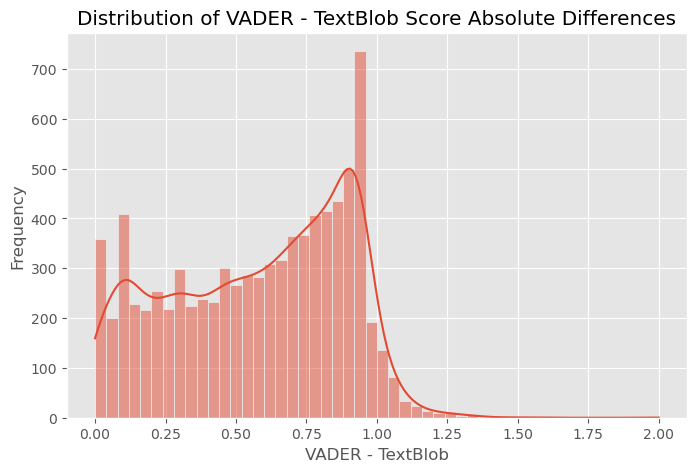

In [189]:
plt.style.use('ggplot')
plt.figure(figsize=(8,5))
sns.histplot(formatted_submissions_df['score_difference_abs'], bins=50, kde=True)
plt.title('Distribution of VADER - TextBlob Score Absolute Differences')
plt.xlabel('VADER - TextBlob')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


### Sentiment analysis of only sentences that contain AI or Artificial Intelligence

In [190]:
def extract_ai_sentences(text):
    if pd.isnull(text):
        return ''
    sentences = re.split(r'(?<=[.!?])\s+', text)

    # Filter for 'AI' or 'artificial intelligence' (case-insensitive)
    ai_sentences = [s for s in sentences if re.search(r'\b(AI|artificial intelligence)\b', s, re.IGNORECASE)]
    return ' '.join(ai_sentences)

formatted_submissions_df['ai_mentions'] = formatted_submissions_df['comment_only'].apply(extract_ai_sentences)


/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/4073839660.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [191]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(comment):
    scores = analyzer.polarity_scores(comment)
    return scores['compound']

formatted_submissions_df['vader_score_ai'] = formatted_submissions_df['ai_mentions'].progress_apply(vader_score)

100%|██████████| 8374/8374 [00:34<00:00, 244.85it/s] 
/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/2206152444.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [192]:
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

formatted_submissions_df['textblob_score_ai'] = formatted_submissions_df['ai_mentions'].progress_apply(get_textblob_sentiment)

100%|██████████| 8374/8374 [00:03<00:00, 2268.25it/s]
/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/2229157509.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



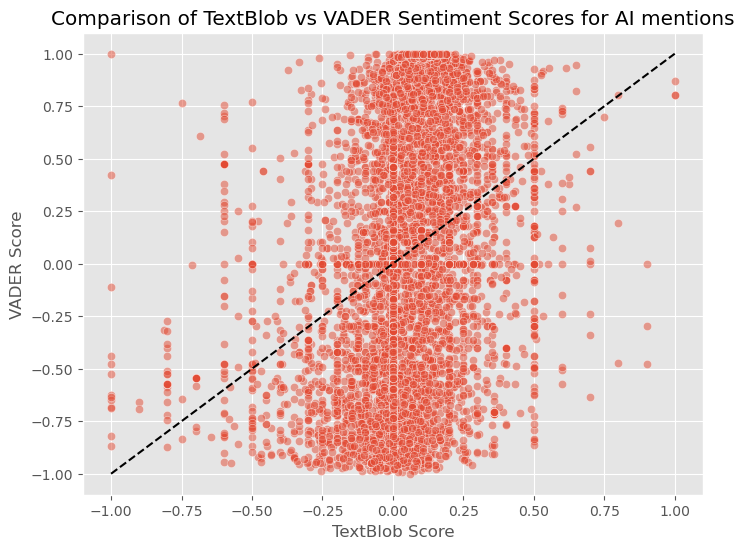

In [193]:
plt.style.use('ggplot')
plt.figure(figsize=(8,6))
sns.scatterplot(data=formatted_submissions_df, x='textblob_score_ai', y='vader_score_ai', alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='black', linestyle='--')
plt.title('Comparison of TextBlob vs VADER Sentiment Scores for AI mentions')
plt.xlabel('TextBlob Score')
plt.ylabel('VADER Score')
plt.grid(True)
plt.show()

In [194]:
formatted_submissions_df['score_difference_ai'] = formatted_submissions_df['vader_score_ai'] - formatted_submissions_df['textblob_score_ai']

formatted_submissions_df['score_difference_abs_ai'] = (formatted_submissions_df['vader_score_ai'] - formatted_submissions_df['textblob_score_ai']).abs()

formatted_submissions_df.sort_values('score_difference_ai', ascending=True).head(10)

/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/378075367.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/3m/chgnvz6n0lvb48zy37bx_p6c0000gn/T/ipykernel_28356/378075367.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,link,respondent,Respondent Type,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai,score_difference_ai,score_difference_abs_ai
5141,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,ELIZABETH SHERWIN,individual,AI-RFI-2025-6174.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","As an artist, I find AI incredibly dishearteni...",0.0009,0.260000,-0.259100,0.259100,"As an artist, I find AI incredibly disheartening.",-0.4754,0.900000,-1.375400,1.375400
5420,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Gabriel Gonzalez,individual,AI-RFI-2025-1786.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","AI steals jobs from Americans, it will continu...",-0.8625,0.500000,-1.362500,1.362500,"AI steals jobs from Americans, it will continu...",-0.8625,0.500000,-1.362500,1.362500
1907,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-4802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",DO NOT ALLOW OPEN AI TO SCOUR THE INTERNET TO ...,-0.8465,0.500000,-1.346500,1.346500,DO NOT ALLOW OPEN AI TO SCOUR THE INTERNET TO ...,-0.8465,0.500000,-1.346500,1.346500
502,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Ann W,individual,AI-RFI-2025-6359.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Please no. We do not need AI taking over every...,-0.7696,0.500000,-1.269600,1.269600,We do not need AI taking over everything becau...,-0.8388,0.500000,-1.338800,1.338800
7059,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Luka Fernandez,individual,AI-RFI-2025-2096.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI has wrought havoc in all creative fields an...,-0.8658,0.150000,-1.015800,1.015800,AI has wrought havoc in all creative fields an...,-0.8360,0.500000,-1.336000,1.336000
8339,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Royale Henry,individual,AI-RFI-2025-4531.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Ai sould not be fair use. Ai is stolen data fr...,-0.6324,0.700000,-1.332400,1.332400,Ai sould not be fair use. Ai is stolen data fr...,-0.6324,0.700000,-1.332400,1.332400
1327,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-3352.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Generative AI is nothing more than an overpric...,0.4678,0.161250,0.306550,0.306550,Generative AI is nothing more than an overpric...,-0.7906,0.500000,-1.290600,1.290600
7847,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Noah Moss,individual,AI-RFI-2025-3813.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",All OpenAI does is steal other peoples' creati...,-0.5223,0.391667,-0.913967,0.913967,"AI should be doing our taxes, not sucking the ...",-0.4717,0.800000,-1.271700,1.271700
5399,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Fred Coppersmith,individual,AI-RFI-2025-6516.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I believe that AI is overhyped and already sho...,-0.7650,0.250000,-1.015000,1.015000,I believe that AI is overhyped and already sho...,-0.7650,0.500000,-1.265000,1.265000
3647,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-9233.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI companies should be held to the rules of th...,-0.9073,0.357143,-1.264443,1.264443,AI companies should be held to the rules of th...,-0.9073,0.357143,-1.264443,1.264443


In [195]:
formatted_submissions_df.sort_values('score_difference_ai', ascending=False).head(10)

,link,respondent,Respondent Type,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai,score_difference_ai,score_difference_abs_ai
6852,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,L C-Woodhouse,individual,AI-RFI-2025-3649.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO N...,0.9996,-1.000000,1.999600,1.999600,NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO N...,0.9996,-1.000000,1.999600,1.999600
5022,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Don Gaze,individual,AI-RFI-2025-5776.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Any and all AI LLMs and artificial intelligenc...,0.4199,-0.472222,0.892122,0.892122,Any and all AI LLMs and artificial intelligenc...,0.7644,-0.750000,1.514400,1.514400
2744,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-6948.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",This sounds an awful lot like saying one could...,0.4215,-1.000000,1.421500,1.421500,This sounds an awful lot like saying one could...,0.4215,-1.000000,1.421500,1.421500
4906,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,David Lebar,individual,AI-RFI-2025-6861.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial Intelligence and anything like it s...,0.8225,-0.100000,0.922500,0.922500,Artificial Intelligence and anything like it s...,0.7579,-0.600000,1.357900,1.357900
7357,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Matthew Thomas,individual,AI-RFI-2025-7320.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Copyrighted material should be protected from ...,0.7184,-0.600000,1.318400,1.318400,Copyrighted material should be protected from ...,0.7184,-0.600000,1.318400,1.318400
3362,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Anonymous,individual,AI-RFI-2025-8568.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial intelligence will do nothing but ha...,0.0964,-0.200000,0.296400,0.296400,Artificial intelligence will do nothing but ha...,0.7027,-0.600000,1.302700,1.302700
296,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Alexis Hurley,individual,AI-RFI-2025-5851.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Please do not allow the destruction of copyrig...,0.9651,-0.039782,1.004882,1.004882,Please do not allow the destruction of copyrig...,0.9221,-0.372917,1.295017,1.295017
3938,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Art Klawitter,individual,AI-RFI-2025-1107.pdf,1,"As of: March 21, 2025\nReceived: March 07, 202...",My greatest concern about artificial intellige...,0.9633,-0.064855,1.028155,1.028155,My greatest concern about artificial intellige...,0.9603,-0.333333,1.293633,1.293633
8510,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Sara Barrett,individual,AI-RFI-2025-5324.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial Intelligence (AI) isn’t a foolproof...,0.7717,-0.108333,0.880033,0.880033,Artificial Intelligence (AI) isn’t a foolproof...,0.6908,-0.600000,1.290800,1.290800
3925,https://files.nitrd.gov/90-fr-9088/AI-RFI-2025...,Ari Fletch,individual,AI-RFI-2025-2186.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",The people's voice must be heard. AI isn't jus...,0.8820,-0.117256,0.999256,0.999256,"AI isn't just bad for artists, its use require...",0.6059,-0.683333,1.289233,1.289233


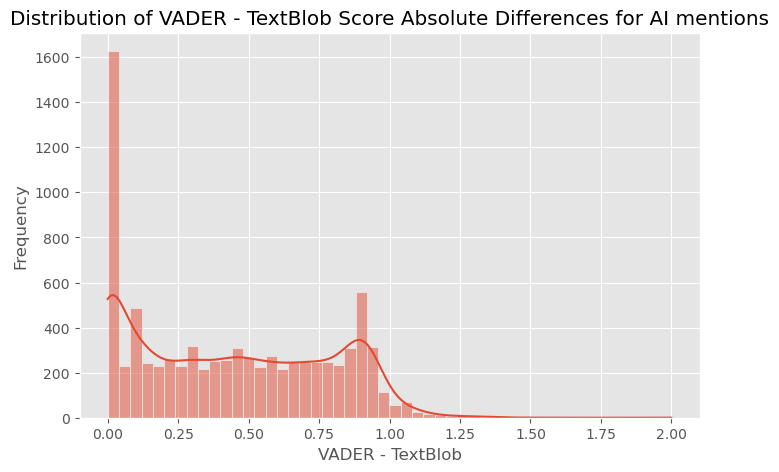

In [196]:
plt.style.use('ggplot')
plt.figure(figsize=(8,5))
sns.histplot(formatted_submissions_df['score_difference_abs_ai'], bins=50, kde=True)
plt.title('Distribution of VADER - TextBlob Score Absolute Differences for AI mentions')
plt.xlabel('VADER - TextBlob')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Since neither Textblob nor VADER are giving consistent, accurate results, I am going to try using chatGPT

In [ ]:
import openai
import pandas as pd
import time

openai.api_key = "YOUR_API_KEY"  # Replace with your API key

def get_sentiment_score(text):
    try:
        response = openai.ChatCompletion.create(
            model="gpt-4",  # or "gpt-3.5-turbo" if using the cheaper model
            messages=[
                {"role": "system", "content": "You are a helpful assistant that performs sentiment analysis."},
                {"role": "user", "content": f"Give a sentiment score from -1 (very negative) to 1 (very positive) for the following text:\n\n{text}"}
            ],
            temperature=0,
        )
        sentiment_str = response.choices[0].message["content"].strip()
        return float(sentiment_str)
    except Exception as e:
        print(f"Error with OpenAI API: {e}")
        return None

# Apply to a sample for testing (to avoid using up tokens too quickly)
sample_df = responses_df.head(10).copy()
sample_df["sentiment_score"] = sample_df["text"].apply(get_sentiment_score)


Try next: ask chatGPT for sentiment

## # - Scrape info from NITRD Table - Waiting for email response
- clean file name and respondent type from [link](https://www.nitrd.gov/coordination-areas/ai/90-fr-9088-responses/)
